In [2]:
import pandas as pd
import random
from datetime import datetime, timedelta

random.seed(42)

# jumlah data
jumlah_data = 947

data = []

kota = ["Jakarta", "Tangerang", "Depok", "Bekasi", "Bogor", "Bandung"]
gender = ["Male", "Female", "M", "F", None]
payment_method = ["Credit Card", "Debit Card", "E-Wallet", "Cash"]
region = ["Jabodetabek", "Jawa Barat", "Jawa Tengah", None]

tanggal_awal = datetime(2023, 1, 1)

for i in range(1, jumlah_data + 1):

    umur = random.choice(
        [
            random.randint(18, 60),
            None,  # missing value
            random.randint(65, 75),  # outlier
        ]
    )

    monthly_spend = random.choice(
        [
            random.randint(150000, 2500000),
            0,  # nilai tidak logis
            random.randint(3000000, 5000000),  # outlier
        ]
    )

    tenure = random.randint(1, 60)
    transaksi = random.choice([random.randint(1, 50), None])  # missing value

    churn = random.choice(["Yes", "No"])

    data.append(
        {
            "CustomerID": f"CUST{i:05d}",
            "JoinDate": (
                tanggal_awal + timedelta(days=random.randint(0, 900))
            ).strftime("%Y-%m-%d"),
            "Age": umur,
            "Gender": random.choice(gender),
            "MonthlySpend": monthly_spend,
            "TenureMonth": tenure,
            "NumTransactions": transaksi,
            "PaymentMethod": random.choice(payment_method),
            "Region": random.choice(region),
            "Churn": churn,
        }
    )

df = pd.DataFrame(data)

df.to_csv("Iik Muhamad Ikmal - 241011750073.csv", index=False)

# print("Iik Muhamad Ikmal - 241011750073.csv berhasil dibuat")

**Membaca file csv**

In [3]:
df = pd.read_csv("Iik Muhamad Ikmal - 241011750073.csv")
df.head()

,CustomerID,JoinDate,Age,Gender,MonthlySpend,TenureMonth,NumTransactions,PaymentMethod,Region,Churn
0,CUST00001,2024-08-27,58.0,F,1303556,9,48.0,Credit Card,Jabodetabek,Yes
1,CUST00002,2024-04-04,23.0,NaN,2269613,36,NaN,E-Wallet,Jabodetabek,Yes
2,CUST00003,2024-01-25,NaN,Male,1315476,49,22.0,E-Wallet,Jawa Tengah,Yes
3,CUST00004,2025-04-29,56.0,NaN,2076967,60,25.0,E-Wallet,Jawa Barat,No
4,CUST00005,2023-10-12,65.0,F,0,6,15.0,E-Wallet,Jawa Barat,No


**Pengecekan data kosong**

In [4]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Age                326
Gender             205
NumTransactions    469
Region             233
dtype: int64

**Pengecekan data statistik awal**

In [5]:
df.describe(include="all")

,CustomerID,JoinDate,Age,Gender,MonthlySpend,TenureMonth,NumTransactions,PaymentMethod,Region,Churn
count,947,947,621.000000,742,9.470000e+02,947.000000,478.000000,947,714,947
unique,947,585,NaN,4,NaN,NaN,NaN,4,3,2
top,CUST00001,2024-03-09,NaN,Male,NaN,NaN,NaN,Credit Card,Jabodetabek,Yes
freq,1,5,NaN,205,NaN,NaN,NaN,246,246,486
mean,NaN,NaN,54.223833,NaN,1.801663e+06,30.942978,26.048117,NaN,NaN,NaN
std,NaN,NaN,17.864358,NaN,1.759978e+06,17.335116,14.737528,NaN,NaN,NaN
min,NaN,NaN,18.000000,NaN,0.000000e+00,1.000000,1.000000,NaN,NaN,NaN
25%,NaN,NaN,39.000000,NaN,0.000000e+00,16.000000,13.000000,NaN,NaN,NaN
50%,NaN,NaN,60.000000,NaN,1.338758e+06,31.000000,26.000000,NaN,NaN,NaN
75%,NaN,NaN,70.000000,NaN,3.547534e+06,46.000000,38.000000,NaN,NaN,NaN


Jumlah data baris dan kolom:

In [6]:
df.shape

(947, 10)

Data kolom

In [7]:
df.columns

Index(['CustomerID', 'JoinDate', 'Age', 'Gender', 'MonthlySpend',
       'TenureMonth', 'NumTransactions', 'PaymentMethod', 'Region', 'Churn'],
      dtype='str')

Data info

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       947 non-null    str    
 1   JoinDate         947 non-null    str    
 2   Age              621 non-null    float64
 3   Gender           742 non-null    str    
 4   MonthlySpend     947 non-null    int64  
 5   TenureMonth      947 non-null    int64  
 6   NumTransactions  478 non-null    float64
 7   PaymentMethod    947 non-null    str    
 8   Region           714 non-null    str    
 9   Churn            947 non-null    str    
dtypes: float64(2), int64(2), str(6)
memory usage: 74.1 KB


Kolom yang bertype object adalah:

In [9]:
df.select_dtypes(include=["object"]).columns

C:\Users\IIK\AppData\Local\Temp\ipykernel_23144\2790643224.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=["object"]).columns


Index(['CustomerID', 'JoinDate', 'Gender', 'PaymentMethod', 'Region', 'Churn'], dtype='str')

Pengelompokan data objek dengan int64/float64

In [10]:
df.groupby("Gender")["NumTransactions"].mean()

Gender
F         27.101010
Female    25.418919
M         26.146067
Male      25.584158
Name: NumTransactions, dtype: float64

Menghitung nilai suatu kolom

In [11]:
df["Gender"].value_counts()

Gender
Male      205
F         196
M         185
Female    156
Name: count, dtype: int64

Menghitung data kosong

In [12]:
df.isnull().sum()

CustomerID           0
JoinDate             0
Age                326
Gender             205
MonthlySpend         0
TenureMonth          0
NumTransactions    469
PaymentMethod        0
Region             233
Churn                0
dtype: int64

Mengisi data yang kosong

In [13]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [14]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [15]:
df["NumTransactions"] = df["NumTransactions"].fillna(df["NumTransactions"].mean())

In [16]:
df["Region"] = df["Region"].fillna(df["Region"].mode()[0])

Pengecekan ulang data yang kosong

In [17]:
df.isnull().sum()

CustomerID         0
JoinDate           0
Age                0
Gender             0
MonthlySpend       0
TenureMonth        0
NumTransactions    0
PaymentMethod      0
Region             0
Churn              0
dtype: int64

Pengelompokan Age

In [18]:
def GroupBy_Age(x):
    import pandas as pd

    if pd.isna(x):
        return "Tidak diketahui"
    if x <= 17:
        return "Anak-anak"
    elif x <= 25:
        return "Remaja"
    elif x <= 55:
        return "Dewasa"
    else:
        return "Lansia"

In [19]:
df.describe(include="all")

,CustomerID,JoinDate,Age,Gender,MonthlySpend,TenureMonth,NumTransactions,PaymentMethod,Region,Churn
count,947,947,947.000000,947,9.470000e+02,947.000000,947.000000,947,947,947
unique,947,585,NaN,4,NaN,NaN,NaN,4,3,2
top,CUST00001,2024-03-09,NaN,Male,NaN,NaN,NaN,Credit Card,Jabodetabek,Yes
freq,1,5,NaN,410,NaN,NaN,NaN,246,479,486
mean,NaN,NaN,54.223833,NaN,1.801663e+06,30.942978,26.048117,NaN,NaN,NaN
std,NaN,NaN,14.462311,NaN,1.759978e+06,17.335116,10.464977,NaN,NaN,NaN
min,NaN,NaN,18.000000,NaN,0.000000e+00,1.000000,1.000000,NaN,NaN,NaN
25%,NaN,NaN,49.500000,NaN,0.000000e+00,16.000000,26.000000,NaN,NaN,NaN
50%,NaN,NaN,54.223833,NaN,1.338758e+06,31.000000,26.048117,NaN,NaN,NaN
75%,NaN,NaN,67.000000,NaN,3.547534e+06,46.000000,26.524059,NaN,NaN,NaN


Konversi data umur dari string ke int

In [20]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

Pengelompokan data umur

In [21]:
df["GroupBy_Age"] = df["Age"].apply(GroupBy_Age)
df["GroupBy_Age"].value_counts()

GroupBy_Age
Dewasa    548
Lansia    347
Remaja     52
Name: count, dtype: int64

Data paling atas

In [22]:
df.head()

,CustomerID,JoinDate,Age,Gender,MonthlySpend,TenureMonth,NumTransactions,PaymentMethod,Region,Churn,GroupBy_Age
0,CUST00001,2024-08-27,58.000000,F,1303556,9,48.000000,Credit Card,Jabodetabek,Yes,Lansia
1,CUST00002,2024-04-04,23.000000,Male,2269613,36,26.048117,E-Wallet,Jabodetabek,Yes,Remaja
2,CUST00003,2024-01-25,54.223833,Male,1315476,49,22.000000,E-Wallet,Jawa Tengah,Yes,Dewasa
3,CUST00004,2025-04-29,56.000000,Male,2076967,60,25.000000,E-Wallet,Jawa Barat,No,Lansia
4,CUST00005,2023-10-12,65.000000,F,0,6,15.000000,E-Wallet,Jawa Barat,No,Lansia


Konversi data JoinDate dari objek ke datetime

In [23]:
df["JoinDate"] = pd.to_datetime(df["JoinDate"], errors="coerce")

Show data

In [24]:
df["JoinDate"].nunique()

585

Format gender menjadi seragam

In [25]:
df["Gender"] = df["Gender"].str.title()

In [26]:
df["Gender"] = df["Gender"].replace("", "Tidak Diketahui")

Mengecek data duplikat

In [27]:
df.duplicated().sum()

np.int64(0)

Menghapus jika ada data duplikat

In [28]:
df = df.drop_duplicates()

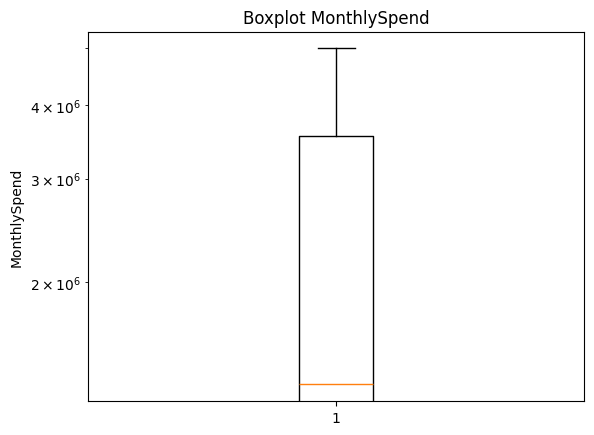

In [29]:
import matplotlib.pyplot as plt

plt.boxplot(df["MonthlySpend"].dropna())
plt.yscale("log")
plt.title("Boxplot MonthlySpend")
plt.ylabel("MonthlySpend")
plt.show()

Melihat data statistic

In [30]:
df["NumTransactions"].describe()

count    947.000000
mean      26.048117
std       10.464977
min        1.000000
25%       26.000000
50%       26.048117
75%       26.524059
max       50.000000
Name: NumTransactions, dtype: float64

### Deteksi Outlier pada `NumTransactions`

Outlier dideteksi menggunakan metode **Interquartile Range (IQR)** dengan menghitung Q1 (25%) dan Q3 (75%). Data dengan nilai **NumTransactions** yang berada di bawah **Q1 − 1.5×IQR** atau di atas **Q3 + 1.5×IQR** dikategorikan sebagai outlier.

In [31]:
Q1 = df["NumTransactions"].quantile(0.25)
Q3 = df["NumTransactions"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = df[
    (df["NumTransactions"] < lower_bound) | (df["NumTransactions"] > upper_bound)
]

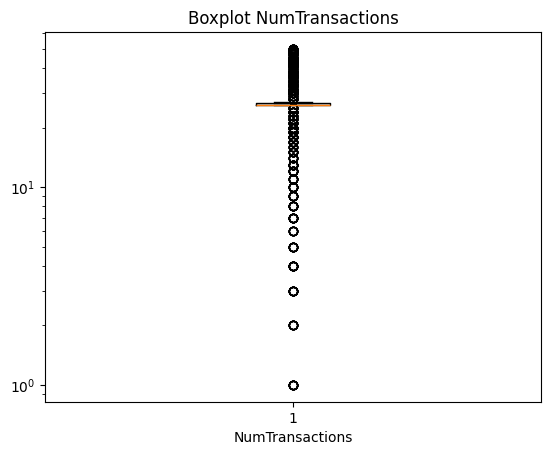

In [32]:
plt.boxplot(df["NumTransactions"].dropna())
plt.yscale("log")
plt.title("Boxplot NumTransactions")
plt.xlabel("NumTransactions")
plt.show()

Kode ini digunakan untuk mengidentifikasi kolom-kolom dengan tipe data kategorikal (object) pada DataFrame.

In [33]:
df.select_dtypes(include="object").columns

C:\Users\IIK\AppData\Local\Temp\ipykernel_23144\1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['CustomerID', 'Gender', 'PaymentMethod', 'Region', 'Churn',
       'GroupBy_Age'],
      dtype='str')

In [34]:
from sklearn.preprocessing import LabelEncoder

le_jenis_kelamin = LabelEncoder()
df["Gender"] = le_jenis_kelamin.fit_transform(df["Gender"])

le_NumTransactions = LabelEncoder()
df["NumTransactions"] = le_NumTransactions.fit_transform(df["NumTransactions"])

le_region = LabelEncoder()
df["Region"] = le_region.fit_transform(df["Region"])

Identifikasi atribut yang akan dinormalisasi

In [35]:
df.select_dtypes(include=["int64", "float64"]).columns

Index(['Age', 'Gender', 'MonthlySpend', 'TenureMonth', 'NumTransactions',
       'Region'],
      dtype='str')

Menentukan kolom yang akan dinormalisasi

In [36]:
kolom_num = [
    "MonthlySpend",
    "TenureMonth",
    "NumTransactions",
]

In [37]:
# encoding
from sklearn.preprocessing import MinMaxScaler

encoder = LabelEncoder()
df["MonthlySpend"] = encoder.fit_transform(df["MonthlySpend"])
df["Region"] = encoder.fit_transform(df["Region"])

In [38]:
# normalize

kolom_num = ["MonthlySpend", "TenureMonth", "NumTransactions"]

scaler = MinMaxScaler()
df_normalizes = df.copy()
df_normalizes[kolom_num] = scaler.fit_transform(df[kolom_num])
df_normalizes[kolom_num].describe()

,MonthlySpend,TenureMonth,NumTransactions
count,947.000000,947.000000,947.000000
mean,0.332101,0.507508,0.515396
std,0.333772,0.293816,0.215563
min,0.000000,0.000000,0.000000
25%,0.000000,0.254237,0.500000
50%,0.246815,0.508475,0.520000
75%,0.623408,0.762712,0.530000
max,1.000000,1.000000,1.000000


Menampilkan data Age dan MonthlySpend paling atas

In [39]:
df[["Age", "MonthlySpend"]].head()

,Age,MonthlySpend
0,58.000000,149
1,23.000000,263
2,54.223833,151
3,56.000000,242
4,65.000000,0


Menampilkan data normalisasi paling atas sebanyak 20 baris

In [40]:
df_normalizes.head(20)

,CustomerID,JoinDate,Age,Gender,MonthlySpend,TenureMonth,NumTransactions,PaymentMethod,Region,Churn,GroupBy_Age
0,CUST00001,2024-08-27,58.000000,0,0.237261,0.135593,0.96,Credit Card,0,Yes,Lansia
1,CUST00002,2024-04-04,23.000000,3,0.418790,0.593220,0.52,E-Wallet,0,Yes,Remaja
2,CUST00003,2024-01-25,54.223833,3,0.240446,0.813559,0.42,E-Wallet,2,Yes,Dewasa
3,CUST00004,2025-04-29,56.000000,3,0.385350,1.000000,0.48,E-Wallet,1,No,Lansia
4,CUST00005,2023-10-12,65.000000,0,0.000000,0.084746,0.28,E-Wallet,1,No,Lansia
5,CUST00006,2023-06-17,41.000000,0,0.859873,0.694915,0.08,Cash,2,Yes,Dewasa
6,CUST00007,2023-10-02,58.000000,3,0.285032,0.237288,0.52,Debit Card,2,No,Lansia
7,CUST00008,2023-09-10,54.223833,3,0.969745,0.491525,0.52,E-Wallet,0,Yes,Dewasa
8,CUST00009,2023-06-06,54.223833,1,0.554140,0.525424,0.10,Cash,0,Yes,Dewasa
9,CUST00010,2025-02-26,71.000000,2,0.000000,0.593220,0.00,Credit Card,2,No,Lansia


Menampilkan data paling atas sebanyak 20 baris

In [41]:
df.head(20)

,CustomerID,JoinDate,Age,Gender,MonthlySpend,TenureMonth,NumTransactions,PaymentMethod,Region,Churn,GroupBy_Age
0,CUST00001,2024-08-27,58.000000,0,149,9,48,Credit Card,0,Yes,Lansia
1,CUST00002,2024-04-04,23.000000,3,263,36,26,E-Wallet,0,Yes,Remaja
2,CUST00003,2024-01-25,54.223833,3,151,49,21,E-Wallet,2,Yes,Dewasa
3,CUST00004,2025-04-29,56.000000,3,242,60,24,E-Wallet,1,No,Lansia
4,CUST00005,2023-10-12,65.000000,0,0,6,14,E-Wallet,1,No,Lansia
5,CUST00006,2023-06-17,41.000000,0,540,42,4,Cash,2,Yes,Dewasa
6,CUST00007,2023-10-02,58.000000,3,179,15,26,Debit Card,2,No,Lansia
7,CUST00008,2023-09-10,54.223833,3,609,30,26,E-Wallet,0,Yes,Dewasa
8,CUST00009,2023-06-06,54.223833,1,348,32,5,Cash,0,Yes,Dewasa
9,CUST00010,2025-02-26,71.000000,2,0,36,0,Credit Card,2,No,Lansia
